In [1]:
import time
import pandas as pd
import json
import numpy as np
from datetime import datetime
from datetime import timezone
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import ListedColormap
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import plotly.graph_objects as go
from plotly.subplots import make_subplots


import itertools
import random

In [2]:
def load_cycles_from_npz(filename):
	"""
	Loads a flattened .npz file and reconstructs the nested dictionary.
	"""
	data = np.load(filename)
	reconstructed = {}
	
	for key in data.files:
		# Split the key (e.g., 'rough_foot_force')
		# We use rsplit once from the right to handle sensor names with underscores
		parts = key.split('_', 1) 
		if len(parts) < 2: continue
		
		terrain, sensor = parts[0], parts[1]
		
		if terrain not in reconstructed:
			reconstructed[terrain] = {}
		
		# Convert the (N, 100, F) array back into a list of (100, F) arrays
		# This makes it compatible with your existing segment_all_trials output
		reconstructed[terrain][sensor] = [cycle for cycle in data[key]]
		
	print(f"Loaded {len(reconstructed)} terrains from {filename}")
	return reconstructed

# --- Execution ---
dataset = load_cycles_from_npz('walking_terrain_datasets.npz')

Loaded 3 terrains from walking_terrain_datasets.npz


In [3]:
import numpy as np

def split_gait_dataset(dataset, train_ratio=0.8, seed=42):
	"""
	Splits the gait cycle dataset into training and testing sets.
	Safely handles sensors with mismatched cycle counts.
	"""
	random.seed(seed)
	train_set = {}
	test_set = {}

	for terrain in dataset.keys():
		# 1. FIND THE MINIMUM CYCLE COUNT ACROSS ALL SENSORS
		# This ensures we don't try to access an index that doesn't exist for a sensor
		sensor_counts = [len(dataset[terrain][s]) for s in dataset[terrain].keys()]
		if not sensor_counts:
			continue
			
		min_cycles = min(sensor_counts)
		
		# 2. Generate indices based on the shortest sensor stream
		indices = list(range(min_cycles))
		random.shuffle(indices)
		
		split_idx = int(min_cycles * train_ratio)
		train_indices = indices[:split_idx]
		test_indices = indices[split_idx:]
		
		train_set[terrain] = {}
		test_set[terrain] = {}

		# 3. Distribute cycles
		for sensor in dataset[terrain].keys():
			all_cycles = dataset[terrain][sensor]
			# We only take the cycles up to min_cycles to stay synchronized
			train_set[terrain][sensor] = [all_cycles[i] for i in train_indices]
			test_set[terrain][sensor] = [all_cycles[i] for i in test_indices]
			
		print(f"Terrain {terrain.upper()}: Used {min_cycles} synchronized cycles. "
			  f"({len(train_indices)} train, {len(test_indices)} test)")

	return train_set, test_set


def simulate_dropped_packets(X_test, drop_rate=0.10, seed=42):
    """
    Simulates signal loss by randomly removing timesteps from each gait cycle.
    
    Parameters:
    - X_test: List of 2D numpy arrays, where each array is (timesteps, features)
    - drop_rate: Float representing the percentage of packets to drop (e.g., 0.10 for 10%)
    - seed: Random seed for reproducibility
    
    Returns:
    - X_dropped: List of degraded 2D numpy arrays.
    """
    np.random.seed(seed)
    X_dropped = []
    
    for cycle in X_test:
        num_timesteps = cycle.shape[0]
        
        # Calculate how many packets to drop and keep
        num_to_drop = int(num_timesteps * drop_rate)
        num_to_keep = num_timesteps - num_to_drop
        
        # Randomly select the indices to KEEP. 
        # We must sort them to ensure time still flows forward!
        keep_indices = np.sort(np.random.choice(num_timesteps, num_to_keep, replace=False))
        
        # Slice the array to keep only the selected timesteps
        degraded_cycle = cycle[keep_indices, :]
        X_dropped.append(degraded_cycle)
        
    return X_dropped

import numpy as np

def simulate_dropped_packets_with_zeros(X_test, drop_rate=0.10, seed=42):
    """
    Simulates signal loss by randomly overwriting entire timesteps with zeros.
    Preserves the original sequence length and structural timeline.
    
    Parameters:
    - X_test: List of 2D numpy arrays (timesteps, features)
    - drop_rate: Float representing the percentage of packets to zero out (e.g., 0.10 for 10%)
    - seed: Random seed for reproducibility
    
    Returns:
    - X_dropped: List of zero-masked 2D numpy arrays with identical original shapes.
    """
    np.random.seed(seed)
    X_dropped = []
    
    for cycle in X_test:
        num_timesteps = cycle.shape[0]
        
        # Calculate how many packet steps to turn into zeros
        num_to_drop = int(num_timesteps * drop_rate)
        
        # Randomly select which time indices will lose their signal
        drop_indices = np.random.choice(num_timesteps, num_to_drop, replace=False)
        
        # Create a deep copy so we don't accidentally corrupt the pristine data in memory
        degraded_cycle = cycle.copy()
        
        # Patch those exact positions with zero across all sensor features
        degraded_cycle[drop_indices, :] = 0.0
        
        X_dropped.append(degraded_cycle)
        
    return X_dropped

def simulate_sensor_noise(X_test, noise_level=0.10, seed=42):
    """
    Simulates electronic and mechanical sensor noise by adding channel-proportional
    Gaussian noise to the gait cycles.
    
    Parameters:
    - X_test: List of 2D numpy arrays (timesteps, features)
    - noise_level: Float representing noise intensity as a percentage of 
                   the channel's standard deviation (e.g., 0.10 for 10% noise)
    - seed: Random seed for reproducibility
    
    Returns:
    - X_noisy: List of noisy 2D numpy arrays with original shapes preserved.
    """
    np.random.seed(seed)
    X_noisy = []
    
    for cycle in X_test:
        # Create a deep copy to protect the pristine dataset in memory
        noisy_cycle = cycle.copy()
        
        # Calculate the standard deviation across time for each individual feature
        feature_stds = np.std(noisy_cycle, axis=0)
        
        # Prevent division/multiplication by zero if a sensor channel is completely flat
        feature_stds[feature_stds == 0] = 1.0
        
        # Generate standard normal noise matching the shape of the cycle
        standard_normal_noise = np.random.normal(loc=0.0, scale=1.0, size=noisy_cycle.shape)
        
        # Scale the noise: Noise = Standard_Noise * noise_level * channel_variance
        scaled_noise = standard_normal_noise * (noise_level * feature_stds)
        
        # Add the noise directly to the original signal
        noisy_cycle += scaled_noise
        X_noisy.append(noisy_cycle)
        
    return X_noisy

import numpy as np

def simulate_sensor_noise_ptp(X_test, noise_level=0.10, seed=42):
    """
    Simulates noise scaled to the Peak-to-Peak (Full-Scale) range of the sensor.
    	
    Yes, absolutely! In fact, scaling noise to the Peak-to-Peak (PTP) value or the Maximum Absolute Magnitude 
    is exactly how hardware engineers typically define the "Full-Scale Signal-to-Noise Ratio (SNR)"
    for physical sensors like load cells and ADCs.
    
    """
    np.random.seed(seed)
    X_noisy = []
    
    for cycle in X_test:
        noisy_cycle = cycle.copy()
        
        # Calculate Peak-to-Peak (Max - Min) across time for each feature
        # This is the "Full-Scale Range" of the sensor for this specific step
        
        feature_scales = np.ptp(noisy_cycle, axis=0)
        # feature_scales = np.max(np.abs(noisy_cycle), axis=0)
        
        # Fallback for completely flat signals to prevent zero-scaling
        feature_scales[feature_scales == 0] = 1.0
        
        standard_normal_noise = np.random.normal(loc=0.0, scale=1.0, size=noisy_cycle.shape)
        
        # Scale the noise by the Peak-to-Peak range
        scaled_noise = standard_normal_noise * (noise_level * feature_scales)
        
        noisy_cycle += scaled_noise
        X_noisy.append(noisy_cycle)
        
    return X_noisy

In [4]:
def format_for_esn(dataset_dict, terrain_to_id_map, sensor_order):
	"""
	Converts the nested dictionary into flat X and y lists for the ESN.
	
	dataset_dict: The output from your split_gait_dataset function.
	terrain_to_id_map: Dictionary mapping string terrain names to integers (e.g., {'concrete': 0, 'grass': 1}).
	sensor_order: A strict list of sensor dictionary keys to ensure columns are always in the same order.
	"""
	X_formatted = []
	y_formatted = []
	
	for terrain, sensors_data in dataset_dict.items():
		if terrain not in terrain_to_id_map:
			continue # Skip terrains we aren't training on
			
		label = terrain_to_id_map[terrain]
		
		# Get the number of cycles for this terrain (they are synchronized)
		n_cycles = len(sensors_data[sensor_order[0]])
		
		for i in range(n_cycles):
			# For cycle 'i', gather data from all 16 joints (K, D, tau)
			cycle_columns = []
			for sensor_name in sensor_order:
				# Ensure it's a numpy array
				sensor_array = np.array(sensors_data[sensor_name][i])
				
				# If the sensor data is 1D (e.g., shape (90,)), reshape to (90, 1) so it stacks horizontally
				if len(sensor_array.shape) == 1:
					sensor_array = sensor_array.reshape(-1, 1)
					
				cycle_columns.append(sensor_array)
			
			# Stack all sensors horizontally to create the (90 timesteps x 48 features) matrix
			full_gait_matrix = np.hstack(cycle_columns)
			
			X_formatted.append(full_gait_matrix)
			y_formatted.append(label)
			
	return X_formatted, np.array(y_formatted)

In [5]:
from env_pred_1 import SupervisedESN
from env_pred_2 import HAPTRClassifier
from env_pred_3 import CNNRNNClassifier
from env_pred_4 import TCNClassifier
from env_pred_5 import SignalTransformerClassifier  

TERRAIN_LABELS = {
	'flat': 0,
	'muddy': 1,
	'water': 2
}

model_list = ["joint_kdf",
			  "leg_kdf",
			  "joint_tor",
			  "leg_grf",
			  "joint_tor_grf"]
sensor_list = [['joint_stiffness_fb', 'joint_damping_fb', 'joint_torque_ff_fb'],
			  ['leg_stiffness', 'leg_damping', 'leg_torque_feedforward'],
			  ['joint_torque_fb'],
			  ['foot_force'],
			  ['joint_torque_fb', 'foot_force']]
# model_arch_list = ['esn', 'haptr', 'cnn_rnn', 'tcn', 'strn']
model_arch_list = ['esn', 'haptr', 'cnn_rnn', 'tcn']
model_arch_obj_list = {}
for model_arch in model_arch_list:
	if model_arch == 'esn':
		model_arch_obj_list[model_arch] = SupervisedESN()
	if model_arch == 'haptr':
		model_arch_obj_list[model_arch] = HAPTRClassifier()
	if model_arch == 'cnn_rnn':
		model_arch_obj_list[model_arch] = CNNRNNClassifier()
	if model_arch == 'tcn':
		model_arch_obj_list[model_arch] = TCNClassifier()
	if model_arch == 'strn':
		model_arch_obj_list[model_arch] = SignalTransformerClassifier()

In [6]:
print("Splitting dataset...")
train_data, test_data = split_gait_dataset(dataset, train_ratio=0.5, seed=42)

Splitting dataset...
Terrain FLAT: Used 62 synchronized cycles. (31 train, 31 test)
Terrain MUDDY: Used 59 synchronized cycles. (29 train, 30 test)
Terrain WATER: Used 53 synchronized cycles. (26 train, 27 test)


# Summary

In [7]:

accuracy_dict = {}

for model_arch in model_arch_list:
    # Testing drop rates from 0% to 90% in increments of 10%
    for drop_rate in np.arange(0.0, 1.00, 0.10):
        print(f"\n--- Model: {model_arch.upper()} | Drop Rate: {drop_rate*100:.0f}% ---")
        print("Formatting data ...")

        X_train, y_train = format_for_esn(train_data, TERRAIN_LABELS, ['joint_stiffness_fb', 'joint_damping_fb', 'joint_torque_ff_fb'])
        X_test, y_test = format_for_esn(test_data, TERRAIN_LABELS, ['joint_stiffness_fb', 'joint_damping_fb', 'joint_torque_ff_fb'])

        # Apply the in-place zero-masking drop simulation
        X_test = simulate_dropped_packets_with_zeros(X_test, drop_rate=drop_rate, seed=100)

        print("Booting up Controller...")
        if model_arch == 'esn':
            model_arch_obj_list[model_arch].load_model(f"model_{model_arch}/env_pred_{model_arch}_best_joint_kdf.npz")
        else:
            model_arch_obj_list[model_arch].load_model(f"model_{model_arch}/env_pred_{model_arch}_best_joint_kdf.pt")

        print("Evaluating on unseen Test Set...")
        y_pred = []

        # Collect all predictions
        for i in range(len(X_test)):
            input_sample = X_test[i]
            
            # Cleaner loop: No padding conditions or checks required anymore!
            predicted_class, confidence = model_arch_obj_list[model_arch].predict(input_sample)
            y_pred.append(predicted_class)

        # Convert to numpy array for fast comparison
        y_pred = np.array(y_pred)

        # Calculate Accuracy
        correct = np.sum(y_pred == y_test)
        accuracy = (correct / len(X_test)) * 100
        print(f"-> Test Accuracy: {accuracy:.2f}%")

        # Map to proper display names for your final dictionary
        model_arch_name = model_arch.upper() if model_arch != 'cnn_rnn' else 'CNN-RNN'

        if model_arch_name not in accuracy_dict:
            accuracy_dict[model_arch_name] = {}

        # Save the result
        accuracy_dict[model_arch_name][f"{drop_rate*100:.0f}%"] = accuracy


--- Model: ESN | Drop Rate: 0% ---
Formatting data ...
Booting up Controller...

[SUCCESS] ESN Model loaded from: 'model_esn/env_pred_esn_best_joint_kdf.npz'
----------------------------------------
💡 Hyperparameters:
   • Reservoir Size: 100 neurons
   • Leak Rate:      0.1
   • Target Classes: 3

⚙️ Matrix Shapes:
   • W_in  (Input -> Reservoir): (100, 48)
   • W_res (Reservoir Dynamics): (100, 100)
   • W_out (Reservoir -> Output): (3, 100)
----------------------------------------

Evaluating on unseen Test Set...
-> Test Accuracy: 94.32%

--- Model: ESN | Drop Rate: 10% ---
Formatting data ...
Booting up Controller...

[SUCCESS] ESN Model loaded from: 'model_esn/env_pred_esn_best_joint_kdf.npz'
----------------------------------------
💡 Hyperparameters:
   • Reservoir Size: 100 neurons
   • Leak Rate:      0.1
   • Target Classes: 3

⚙️ Matrix Shapes:
   • W_in  (Input -> Reservoir): (100, 48)
   • W_res (Reservoir Dynamics): (100, 100)
   • W_out (Reservoir -> Output): (3, 100)
-

In [8]:
print("\nFinal Accuracy Comparison:", accuracy_dict)


Final Accuracy Comparison: {'ESN': {'0%': 94.31818181818183, '10%': 94.31818181818183, '20%': 89.77272727272727, '30%': 89.77272727272727, '40%': 89.77272727272727, '50%': 87.5, '60%': 90.9090909090909, '70%': 88.63636363636364, '80%': 87.5, '90%': 85.22727272727273}, 'HAPTR': {'0%': 98.86363636363636, '10%': 93.18181818181817, '20%': 87.5, '30%': 72.72727272727273, '40%': 60.22727272727273, '50%': 51.13636363636363, '60%': 36.36363636363637, '70%': 30.681818181818183, '80%': 30.681818181818183, '90%': 30.681818181818183}, 'CNN-RNN': {'0%': 95.45454545454545, '10%': 94.31818181818183, '20%': 93.18181818181817, '30%': 87.5, '40%': 81.81818181818183, '50%': 76.13636363636364, '60%': 75.0, '70%': 71.5909090909091, '80%': 67.04545454545455, '90%': 54.54545454545454}, 'TCN': {'0%': 97.72727272727273, '10%': 97.72727272727273, '20%': 97.72727272727273, '30%': 97.72727272727273, '40%': 95.45454545454545, '50%': 93.18181818181817, '60%': 86.36363636363636, '70%': 78.4090909090909, '80%': 68.1


Generating Temporal Robustness Chart...


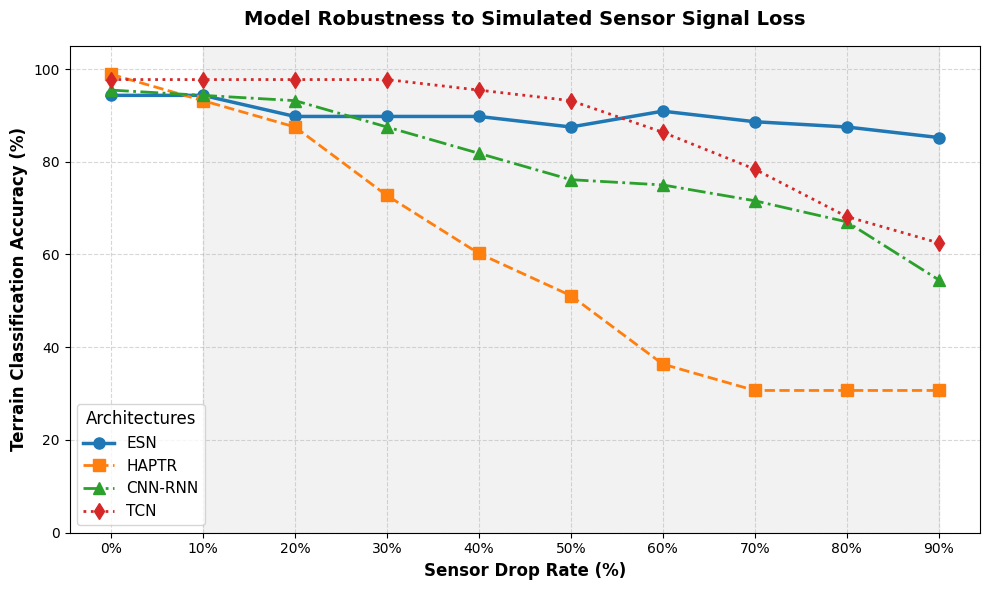

[SUCCESS] Robustness plot saved as 'dropped_packet_robustness.png'


In [9]:
import matplotlib.pyplot as plt

# --- 7. Plotting the Degradation Curve ---
print("\nGenerating Temporal Robustness Chart...")

plt.figure(figsize=(10, 6))

# Define clean styles to match top-tier academic journals (ICRA/IROS)
styles = {
    'ESN': {'color': '#1f77b4', 'marker': 'o', 'linewidth': 2.5, 'linestyle': '-'},
    'HAPTR': {'color': '#ff7f0e', 'marker': 's', 'linewidth': 2, 'linestyle': '--'},
    'CNN-RNN': {'color': '#2ca02c', 'marker': '^', 'linewidth': 2, 'linestyle': '-.'},
    'TCN': {'color': '#d62728', 'marker': 'd', 'linewidth': 2, 'linestyle': ':'},
    'STRN': {'color': '#9467bd', 'marker': 'v', 'linewidth': 2, 'linestyle': '--'}
}

# Extract the drop rates from the inner dictionary keys dynamically
# e.g., ['5% Drop Rate', '10% Drop Rate', '20% Drop Rate', '50% Drop Rate']
drop_labels = list(next(iter(accuracy_dict.values())).keys())

for model_name, drops in accuracy_dict.items():
    # Fetch accuracies in order matching the drop labels
    accuracies = [drops[label] for label in drop_labels]
    
    # Get the designated visual style if defined, otherwise fallback to defaults
    style = styles.get(model_name, {'color': None, 'marker': 'o', 'linewidth': 2, 'linestyle': '-'})
    
    plt.plot(drop_labels, accuracies, label=model_name,
             color=style['color'],
             marker=style['marker'],
             linewidth=style['linewidth'],
             linestyle=style['linestyle'],
             markersize=8)

# Aesthetics and annotations
plt.title('Model Robustness to Simulated Sensor Signal Loss', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Sensor Drop Rate (%)', fontsize=12, fontweight='bold')
plt.ylabel('Terrain Classification Accuracy (%)', fontsize=12, fontweight='bold')
plt.ylim(0, 105)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Architectures', fontsize=11, title_fontsize=12, loc='lower left')

# Shading the region where the continuous state integration dominates
plt.axvspan(drop_labels[1], drop_labels[-1], color='gray', alpha=0.1, label='ESN Dominance Zone')

plt.tight_layout()

# Save image file directly
# plt.savefig('dropped_packet_robustness.png', dpi=300)
plt.show()

print("[SUCCESS] Robustness plot saved as 'dropped_packet_robustness.png'")

# Test Continuous

In [10]:
import numpy as np

def create_continuous_test_stream(X_test, y_test, transition_blend_steps=10):
    """
    Stitches isolated gait cycles together into one massive continuous stream.
    
    Returns:
    - continuous_stream: (Total_Timesteps, Features)
    - ground_truth_labels: (Total_Timesteps,) matching the true terrain at that exact millisecond.
    """
    stream_list = []
    label_list = []
    
    # Shuffle the test data so the terrains are randomized (e.g., Flat -> Mud -> Flat -> Water)
    indices = np.arange(len(X_test))
    np.random.shuffle(indices)
    
    for idx in indices:
        cycle = X_test[idx]
        terrain_label = y_test[idx]
        
        stream_list.append(cycle)
        # Create a label for every single timestep in this cycle
        label_list.extend([terrain_label] * len(cycle))
        
    # Concatenate vertically to create the continuous timeline
    continuous_stream = np.vstack(stream_list)
    ground_truth_labels = np.array(label_list)
    
    return continuous_stream, ground_truth_labels

# Generate the simulated stream
print("Stitching test data into a continuous stream...")
X_stream, y_stream_labels = create_continuous_test_stream(X_test, y_test)
print(f"Continuous Stream Shape: {X_stream.shape}")

Stitching test data into a continuous stream...
Continuous Stream Shape: (8800, 48)


In [11]:
import time
import numpy as np

def evaluate_continuous_stream(model, model_name, X_stream, y_labels, window_size=160, stride=5):
    print(f"\n--- Running Continuous Evaluation: {model_name} ---")
    
    total_timesteps = len(X_stream)
    predictions = []
    true_labels = []
    latencies = []
    eval_timestamps = [] # <-- NEW: We must track exactly WHEN predictions happened
    
    # 1. DYNAMIC START TIME: ESN starts immediately, DL waits for buffer
    start_t = 0 if model_name == 'ESN' else window_size
    
    # Slide the window across the stream
    for t in range(start_t, total_timesteps, stride):
        
        # 2. Grab the current data
        if model_name == 'ESN':
            # ESN only needs the current timestep
            input_data = X_stream[t:t+1] 
        else:
            # DL models need the full historical window
            input_data = X_stream[t-window_size:t]
            
        # 3. Run Inference and measure latency
        start_time = time.perf_counter()
        predicted_class, _ = model.predict(input_data)
        end_time = time.perf_counter()
        
        latencies.append((end_time - start_time) * 1000)
        predictions.append(predicted_class)
        true_labels.append(y_labels[t])
        eval_timestamps.append(t) # Record the physical time of this prediction
        
    # Calculate Metrics
    predictions = np.array(predictions)
    true_labels = np.array(true_labels)
    eval_timestamps = np.array(eval_timestamps)
    
    accuracy = np.mean(predictions == true_labels) * 100
    avg_latency = np.mean(latencies)
    max_latency = np.max(latencies)
    
    print(f"Continuous Accuracy: {accuracy:.2f}%")
    print(f"Average Inference Latency: {avg_latency:.2f} ms")
    print(f"Max Inference Latency: {max_latency:.2f} ms")
    # We now return eval_timestamps so the plotting script knows where to put them!
    return predictions, true_labels, latencies, eval_timestamps

In [12]:
import numpy as np

# 1. Ensure the continuous stream is stitched together first
print("Stitching test data into a continuous stream...")
X_stream, y_stream_labels = create_continuous_test_stream(X_test, y_test)
print(f"Continuous Stream Shape: {X_stream.shape}") 

# ==========================================
# THE FIX: DYNAMIC WINDOW SIZING
# ==========================================
# Dynamically extract the exact sequence length the models were trained on!
WINDOW_SIZE = X_test[0].shape[0]  
STRIDE = 5  # The model runs inference every 5 timesteps

print(f"Sliding Window Size locked to: {WINDOW_SIZE} timesteps")
# ==========================================

# Dictionary to hold the final benchmark results
continuous_results = {}

for model_arch in model_arch_list:
    model_arch_name = model_arch.upper() if model_arch != 'cnn_rnn' else 'CNN-RNN'
    
    print(f"\n=========================================")
    print(f"STARTING CONTINUOUS STREAM TEST: {model_arch_name}")
    print(f"=========================================")

    # Load the best pre-trained model for this architecture
    if model_arch == 'esn':
        model_arch_obj_list[model_arch].load_model(f"model_{model_arch}/env_pred_{model_arch}_best_joint_kdf.npz")
        
        # CRITICAL: Reset the ESN's internal reservoir state before starting a new stream
        # (Assuming your ESN class has a method to clear the state vector)
        if hasattr(model_arch_obj_list[model_arch], 'reset_state'):
            model_arch_obj_list[model_arch].reset_state()
            print("Cleared ESN reservoir state.")
    else:
        model_arch_obj_list[model_arch].load_model(f"model_{model_arch}/env_pred_{model_arch}_best_joint_kdf.pt")

    # Run the continuous evaluation
    predictions, true_labels, latencies, eval_timestamps = evaluate_continuous_stream(
        model=model_arch_obj_list[model_arch],
        model_name=model_arch_name,
        X_stream=X_stream,
        y_labels=y_stream_labels,
        window_size=WINDOW_SIZE,
        stride=STRIDE
    )

    # Store the final calculated metrics
    # Store the final calculated metrics AND the raw predictions
    continuous_results[model_arch_name] = {
        'accuracy': np.mean(predictions == true_labels) * 100,
        'avg_latency_ms': np.mean(latencies),
        'max_latency_ms': np.max(latencies), # (or np.std if you prefer variance)
        'predictions': predictions,
        'eval_timestamps': eval_timestamps  # <-- ADD THIS LINE
    }

# ==========================================
# Print Final Professional Benchmark Table
# ==========================================
print("\n" + "="*60)
print("🏆 FINAL CONTINUOUS CLASSIFICATION BENCHMARK 🏆")
print("="*60)
print(f"{'Model':<12} | {'Accuracy (%)':<14} | {'Avg Latency':<14} | {'Max Latency Spike'}")
print("-" * 60)

for model_name, metrics in continuous_results.items():
    print(f"{model_name:<12} | {metrics['accuracy']:>12.2f} % | {metrics['avg_latency_ms']:>11.2f} ms | {metrics['max_latency_ms']:>13.2f} ms")
    
print("="*60 + "\n")

Stitching test data into a continuous stream...
Continuous Stream Shape: (8800, 48)
Sliding Window Size locked to: 100 timesteps

STARTING CONTINUOUS STREAM TEST: ESN

[SUCCESS] ESN Model loaded from: 'model_esn/env_pred_esn_best_joint_kdf.npz'
----------------------------------------
💡 Hyperparameters:
   • Reservoir Size: 100 neurons
   • Leak Rate:      0.1
   • Target Classes: 3

⚙️ Matrix Shapes:
   • W_in  (Input -> Reservoir): (100, 48)
   • W_res (Reservoir Dynamics): (100, 100)
   • W_out (Reservoir -> Output): (3, 100)
----------------------------------------


--- Running Continuous Evaluation: ESN ---
Continuous Accuracy: 36.25%
Average Inference Latency: 0.10 ms
Max Inference Latency: 9.59 ms

STARTING CONTINUOUS STREAM TEST: HAPTR

[SUCCESS] HAPTR Model loaded from: 'model_haptr/env_pred_haptr_best_joint_kdf.pt'
----------------------------------------
💡 Hyperparameters:
   • Variant:        Large (Layers: 8, Heads: 8)
   • Target Classes: 3
   • Sequence Length:100 steps

Generating zero-latency startup plot...


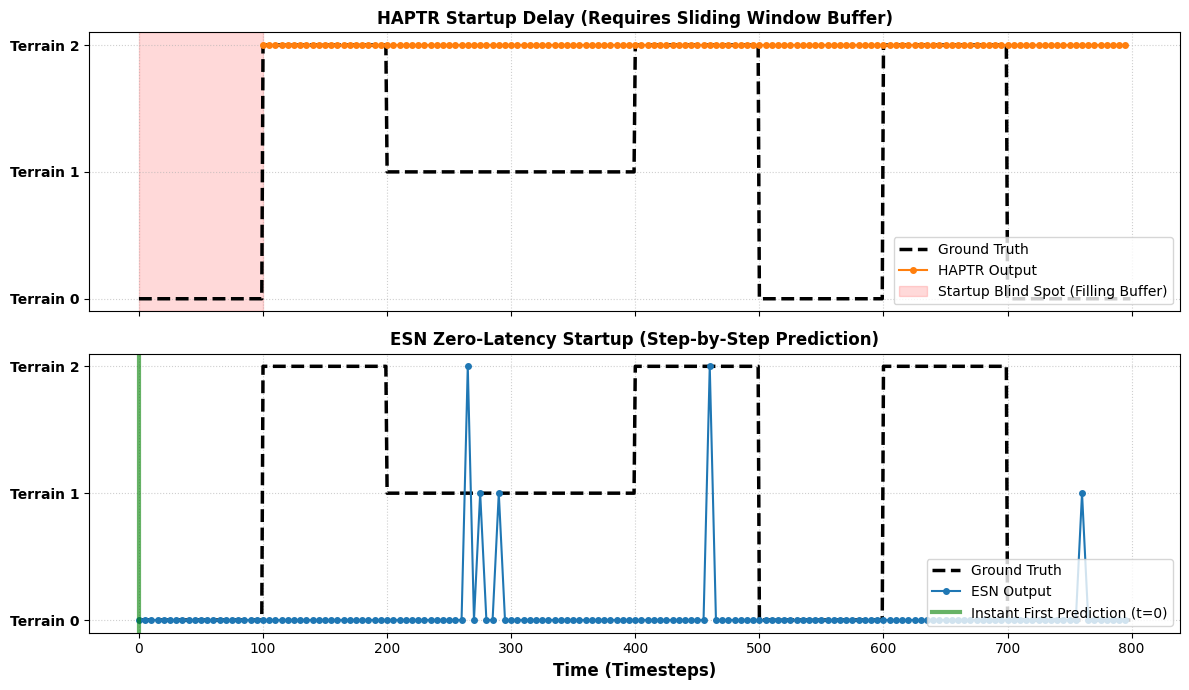

[SUCCESS] Startup comparison plot saved as 'real_startup_comparison.png'


In [13]:
import matplotlib.pyplot as plt
import numpy as np

print("Generating zero-latency startup plot...")

# Focus on the first 800 timesteps to clearly see the startup phase and first terrain transition
PLOT_START = 0
PLOT_END = 800  

time_limit = min(PLOT_END, len(y_stream_labels))
t_axis_true = np.arange(PLOT_START, time_limit)
y_true_slice = y_stream_labels[PLOT_START:time_limit]

# Select which deep learning model you want to compare against the ESN
# (Make sure this string matches exactly what printed in your benchmark table, e.g., 'HAPTR' or 'TCN')
dl_model_name = 'HAPTR' 
esn_model_name = 'ESN'

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True, sharey=True)

# Map y-axis cleanly based on the unique terrains in your dataset
unique_terrains = np.unique(y_stream_labels)
terrain_names = [f"Terrain {int(i)}" for i in unique_terrains] 
yticks = range(len(unique_terrains))

# ==========================================
# PANEL 1: Deep Learning Model (Sliding Window)
# ==========================================
ax1.plot(t_axis_true, y_true_slice, color='black', linewidth=2.5, linestyle='--', label='Ground Truth')

if dl_model_name in continuous_results:
    t_dl = continuous_results[dl_model_name]['eval_timestamps']
    y_dl = continuous_results[dl_model_name]['predictions']

    # Filter only the points that fall in our plot window
    mask_dl = (t_dl >= PLOT_START) & (t_dl < time_limit)
    ax1.plot(t_dl[mask_dl], y_dl[mask_dl], color='#ff7f0e', 
             marker='o', markersize=4, linestyle='-', linewidth=1.5, label=f'{dl_model_name} Output')

    # Highlight the empty buffer zone dynamically
    if len(t_dl) > 0:
        first_prediction_time = t_dl[0]
        ax1.axvspan(0, first_prediction_time, color='red', alpha=0.15, label='Startup Blind Spot (Filling Buffer)')

ax1.set_title(f'{dl_model_name} Startup Delay (Requires Sliding Window Buffer)', fontsize=12, fontweight='bold')
ax1.set_yticks(yticks)
ax1.set_yticklabels(terrain_names, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='lower right')

# ==========================================
# PANEL 2: ESN
# ==========================================
ax2.plot(t_axis_true, y_true_slice, color='black', linewidth=2.5, linestyle='--', label='Ground Truth')

if esn_model_name in continuous_results:
    t_esn = continuous_results[esn_model_name]['eval_timestamps']
    y_esn = continuous_results[esn_model_name]['predictions']

    # Filter only the points that fall in our plot window
    mask_esn = (t_esn >= PLOT_START) & (t_esn < time_limit)
    ax2.plot(t_esn[mask_esn], y_esn[mask_esn], color='#1f77b4', 
             marker='o', markersize=4, linestyle='-', linewidth=1.5, label=f'{esn_model_name} Output')

ax2.set_title('ESN Zero-Latency Startup (Step-by-Step Prediction)', fontsize=12, fontweight='bold')
ax2.set_yticks(yticks)
ax2.set_yticklabels(terrain_names, fontweight='bold')
ax2.set_xlabel('Time (Timesteps)', fontsize=12, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.6)

# Highlight immediate start
ax2.axvline(x=0, color='green', linestyle='-', linewidth=3, alpha=0.6, label='Instant First Prediction (t=0)')
ax2.legend(loc='lower right')

plt.tight_layout()
#plt.savefig('real_startup_comparison.png', dpi=300)
plt.show()

print("[SUCCESS] Startup comparison plot saved as 'real_startup_comparison.png'")

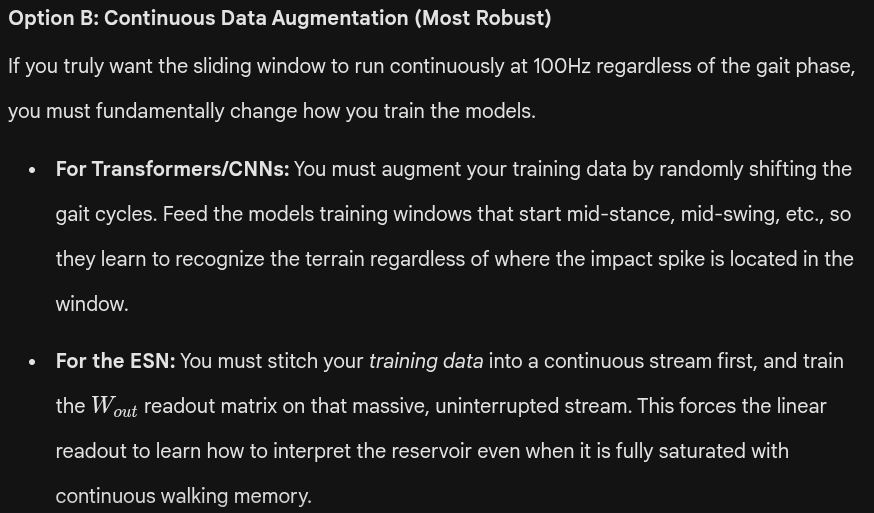

# Plot Latency

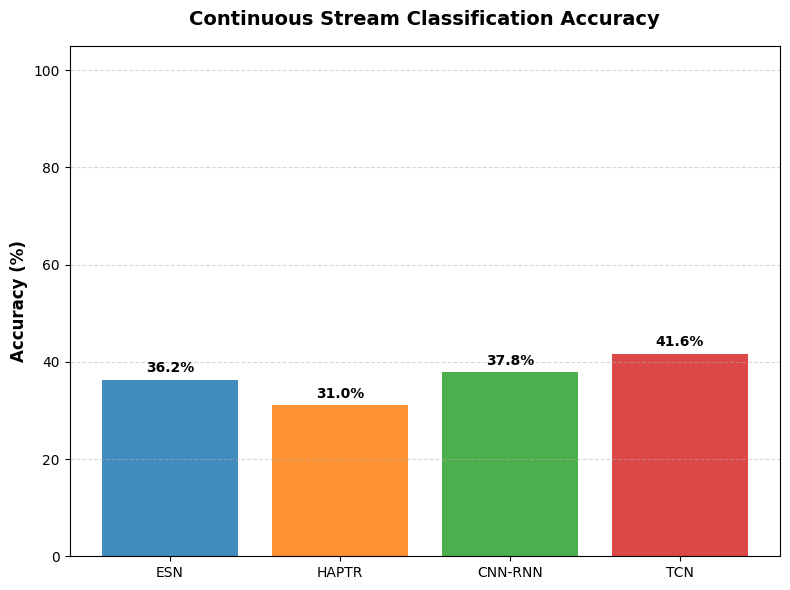

[SUCCESS] Accuracy plot saved as 'continuous_accuracy.png'


In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Extract data dynamically from your continuous_results dictionary
models = list(continuous_results.keys())
accuracies = [continuous_results[m]['accuracy'] for m in models]
avg_latencies = [continuous_results[m]['avg_latency_ms'] for m in models]
max_latencies = [continuous_results[m]['max_latency_ms'] for m in models]

# ==========================================
# PLOT 1: Accuracy Bar Chart
# ==========================================
plt.figure(figsize=(8, 6))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
bars1 = plt.bar(models, accuracies, color=colors, alpha=0.85)

plt.title('Continuous Stream Classification Accuracy', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
plt.ylim(0, 105) # Starting at 0 to emphasize full scale
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add exact percentage labels on top of bars
for bar in bars1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.1f}%", 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
#plt.savefig('continuous_accuracy.png', dpi=300)
plt.show()
print("[SUCCESS] Accuracy plot saved as 'continuous_accuracy.png'")

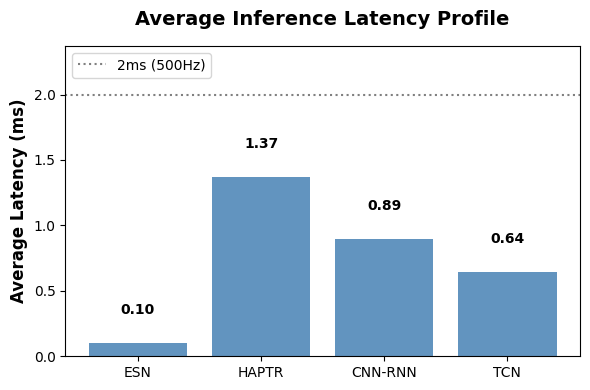

[SUCCESS] Average Latency plot saved as 'continuous_latency_avg.png'


In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Extract data dynamically from your continuous_results dictionary
models = list(continuous_results.keys())
avg_latencies = [continuous_results[m]['avg_latency_ms'] for m in models]

# ==========================================
# PLOT 2: Average Latency Profile
# ==========================================
plt.figure(figsize=(6, 4))

# We no longer need grouped bars, so we plot directly
bars = plt.bar(models, avg_latencies, color='steelblue', alpha=0.85)

plt.title('Average Inference Latency Profile', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Average Latency (ms)', fontsize=12, fontweight='bold')

# Setting the y-limit slightly above 10 to give the 10ms line some breathing room
plt.ylim(0, max(avg_latencies) + 1) 
# plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add horizontal lines representing typical control loop deadlines
# plt.axhline(y=10, color='black', linestyle='--', linewidth=1.5, label='10ms (100Hz) Deadline')
plt.axhline(y=2, color='gray', linestyle=':', linewidth=1.5, label='2ms (500Hz)')
plt.legend(loc='upper left', fontsize=10)

# Add exact millisecond labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.2, f"{yval:.2f}", 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('continuous_latency_avg.png', dpi=300)
plt.show()

print("[SUCCESS] Average Latency plot saved as 'continuous_latency_avg.png'")

/tmp/ipykernel_39017/1317465252.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


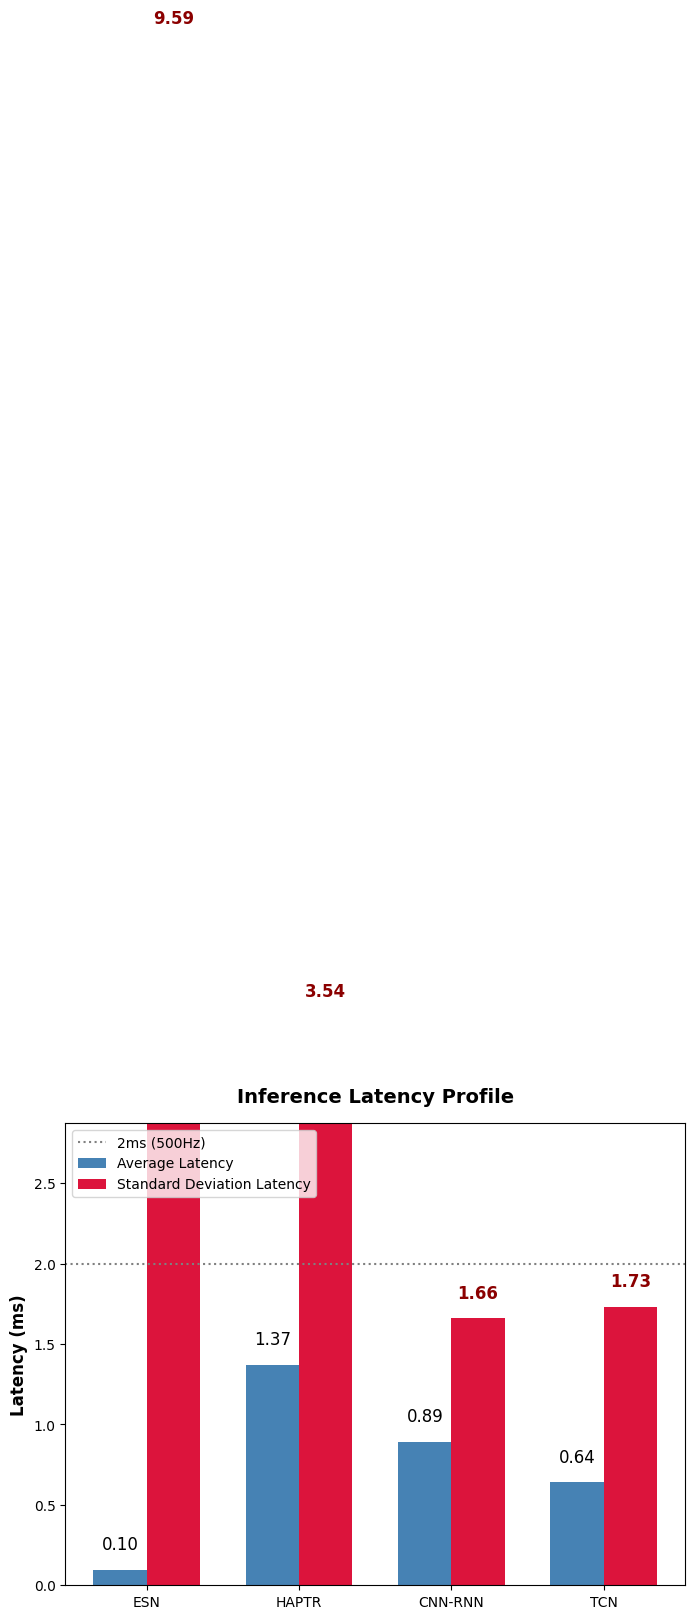

[SUCCESS] Latency plot saved as 'continuous_latency.png'


In [16]:
# ==========================================
# PLOT 2: Latency Profile (Avg vs Max)
# ==========================================
plt.figure(figsize=(8, 6))

x = np.arange(len(models))
width = 0.35

# Grouped bars
bars2 = plt.bar(x - width/2, avg_latencies, width, label='Average Latency', color='steelblue')
bars3 = plt.bar(x + width/2, max_latencies, width, label='Standard Deviation Latency', color='crimson')

plt.title('Inference Latency Profile', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Latency (ms)', fontsize=12, fontweight='bold')
plt.xticks(x, models) # Set x-ticks and labels

# Add horizontal lines representing typical control loop deadlines
plt.axhline(y=2, color='gray', linestyle=':', linewidth=1.5, label='2ms (500Hz)')
plt.legend(loc='upper left', fontsize=10)
plt.ylim(0, max(avg_latencies) + 1.5) 

# Add exact millisecond labels on top of the bars
for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f"{yval:.2f}", ha='center', va='bottom', fontsize=12)
for bar in bars3:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f"{yval:.2f}", ha='center', va='bottom', fontsize=12, color='darkred', fontweight='bold')

plt.tight_layout()
# plt.savefig('continuous_latency.png', dpi=300)
plt.show()
print("[SUCCESS] Latency plot saved as 'continuous_latency.png'")